In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv("/content/data.csv")

In [43]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [45]:
df.isnull().sum()

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
approx_cost(for two people),0
listed_in(type),0


In [46]:
# Remove repeating character in rate (i.e. 5)
def handleRating(rate):
  rate = str(rate).split('/')
  rate = rate[0]
  return float(rate)

df['rate'] = df['rate'].apply(handleRating)
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


Text(0.5, 0, 'Types of Restaurants')

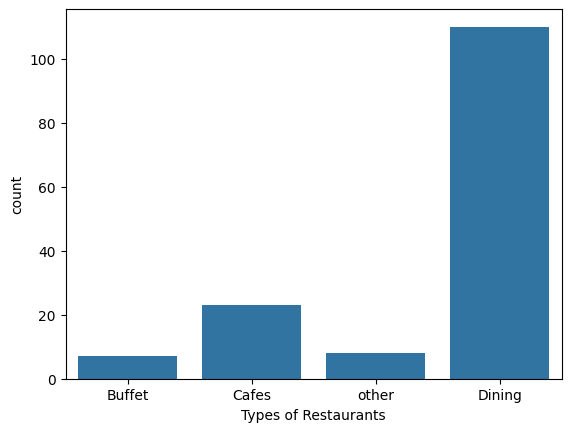

In [47]:
sns.countplot(x=df['listed_in(type)'])
plt.xlabel('Types of Restaurants')

1. What type of restaurant do the majority of customers order from?

Answer: The majority of customers order from Dining

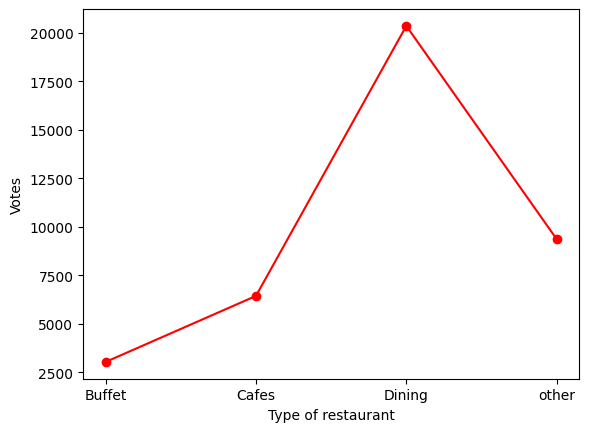

In [48]:
grouped_data = df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grouped_data})
plt.plot(result, c="red", marker="o")
plt.xlabel("Type of restaurant")
plt.ylabel("Votes")
plt.show()


2. How many votes has each type of restaurant received from customers?

Answer: Dining received the highest vote, then other, then cafes and then buffet

Text(0.5, 1.0, 'Ratings Distribution')

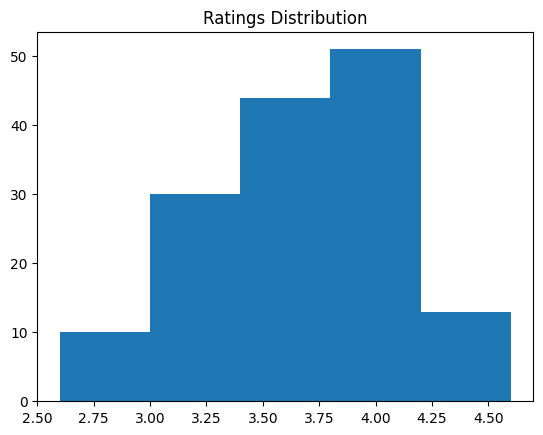

In [49]:
plt.hist(df['rate'], bins=5)
plt.title("Ratings Distribution")

3. What are the ratings that the majority of restaurants have received?

Answer: The majority of restaurants have received rating between 3.5 - 4

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

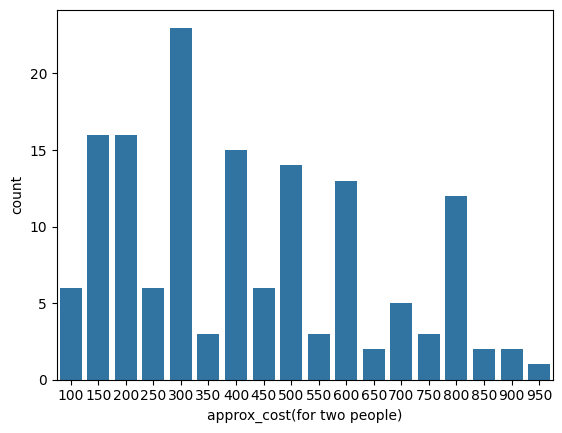

In [50]:
expense = df['approx_cost(for two people)']
sns.countplot(x=expense)

4. Zomato has observed that most couples order most of their food online. What is their average spending on each order?

Answer: 300 is their average spending on each order